In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
filtered = pd.read_csv('bobcat_155_True.csv')
unfiltered = pd.read_csv('bobcat_155_False.csv')
# FILTERING BY PEOPLE WITH SUBJECT ID = 155 - 665 train, 214 valid, 215 test
# Parse comma-separated IDs
filtered['q_ids'] = filtered['sampled_q_ids'].str.split(',')
filtered['subj_ids'] = filtered['sampled_subject_ids'].str.split(',')
unfiltered['q_ids'] = unfiltered['sampled_q_ids'].str.split(',')
unfiltered['subj_ids'] = unfiltered['sampled_subject_ids'].str.split(',')

In [13]:
all_subj_filtered = [s for subj_list in filtered['subj_ids'] for s in subj_list]
all_subj_unfiltered = [s for subj_list in unfiltered['subj_ids'] for s in subj_list]

subj_counts_f = pd.Series(all_subj_filtered).value_counts()
subj_counts_u = pd.Series(all_subj_unfiltered).value_counts()

comparison = pd.DataFrame({
    'Filtered': subj_counts_f,
    'Unfiltered': subj_counts_u
}).fillna(0).astype(int)
comparison['Difference'] = comparison['Filtered'] - comparison['Unfiltered']
comparison2 = comparison.sort_values('Difference', ascending=False)
print(comparison.head(20))
print("="*40)
print(comparison2.head(20))

     Filtered  Unfiltered  Difference
114       140         495        -355
117        47         455        -408
125        58          38          20
126        68         237        -169
127       269         251          18
128       425         146         279
129        12          35         -23
130         1          46         -45
135         0          14         -14
137       288          64         224
146        92         254        -162
148       649         716         -67
151       103           5          98
153       190         193          -3
154       156          25         131
155       343         802        -459
156      1693         394        1299
163       742         211         531
164       558         885        -327
165        29         406        -377
     Filtered  Unfiltered  Difference
156      1693         394        1299
189       803          13         790
163       742         211         531
3         892         470         422
44        55

In [8]:
# 2. Per-student overlap
overlaps = []
for _, f_row in filtered.iterrows():
    u_row = unfiltered[unfiltered['user_id'] == f_row['user_id']]
    if not u_row.empty:
        u_row = u_row.iloc[0]
        
        q_f = set(f_row['q_ids'])
        q_u = set(u_row['q_ids'])
        s_f = set(f_row['subj_ids'])
        s_u = set(u_row['subj_ids'])
        
        overlaps.append({
            'user_id': f_row['user_id'],
            'q_overlap': len(q_f & q_u),
            'q_overlap_pct': len(q_f & q_u) / len(q_f) * 100,
            's_overlap': len(s_f & s_u),
            's_overlap_pct': len(s_f & s_u) / len(s_f) * 100
        })

overlap_df = pd.DataFrame(overlaps)

print(f"Average Question Overlap: {overlap_df['q_overlap_pct'].mean():.1f}%")
print(f"Average Subject Overlap: {overlap_df['s_overlap_pct'].mean():.1f}%")
print(f"\nStudents analyzed: {len(overlap_df)}")


Average Question Overlap: 6.2%
Average Subject Overlap: 41.7%

Students analyzed: 983


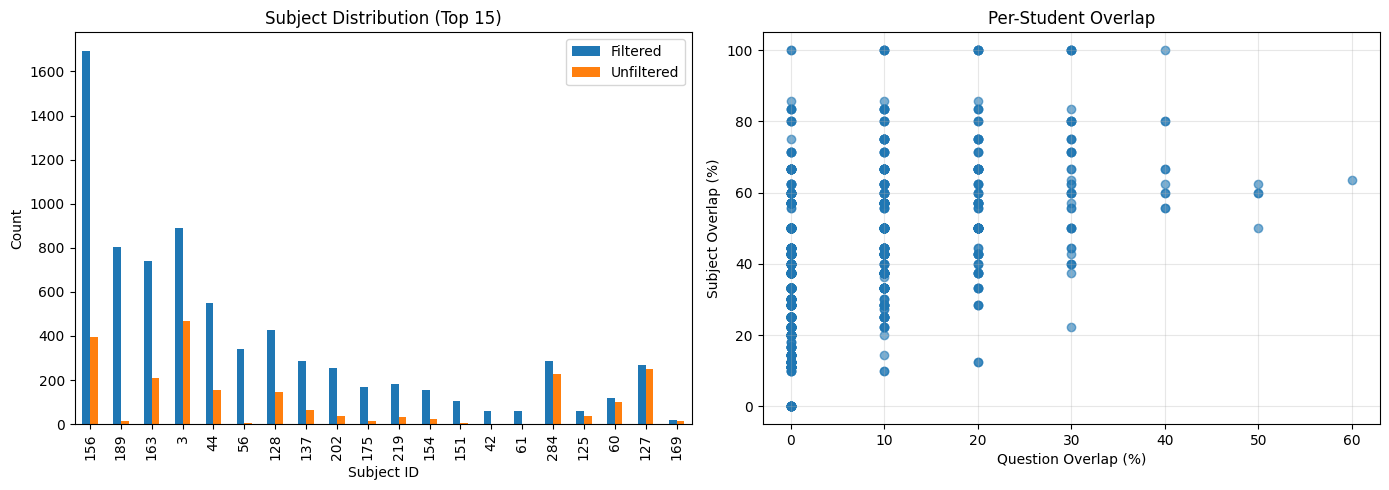

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subject distribution
top_subjects = comparison2.head(20)
top_subjects[['Filtered', 'Unfiltered']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Subject Distribution (Top 15)')
axes[0].set_xlabel('Subject ID')
axes[0].set_ylabel('Count')
axes[0].legend(['Filtered', 'Unfiltered'])

# Overlap scatter
axes[1].scatter(overlap_df['q_overlap_pct'], overlap_df['s_overlap_pct'], alpha=0.6)
axes[1].set_xlabel('Question Overlap (%)')
axes[1].set_ylabel('Subject Overlap (%)')
axes[1].set_title('Per-Student Overlap')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

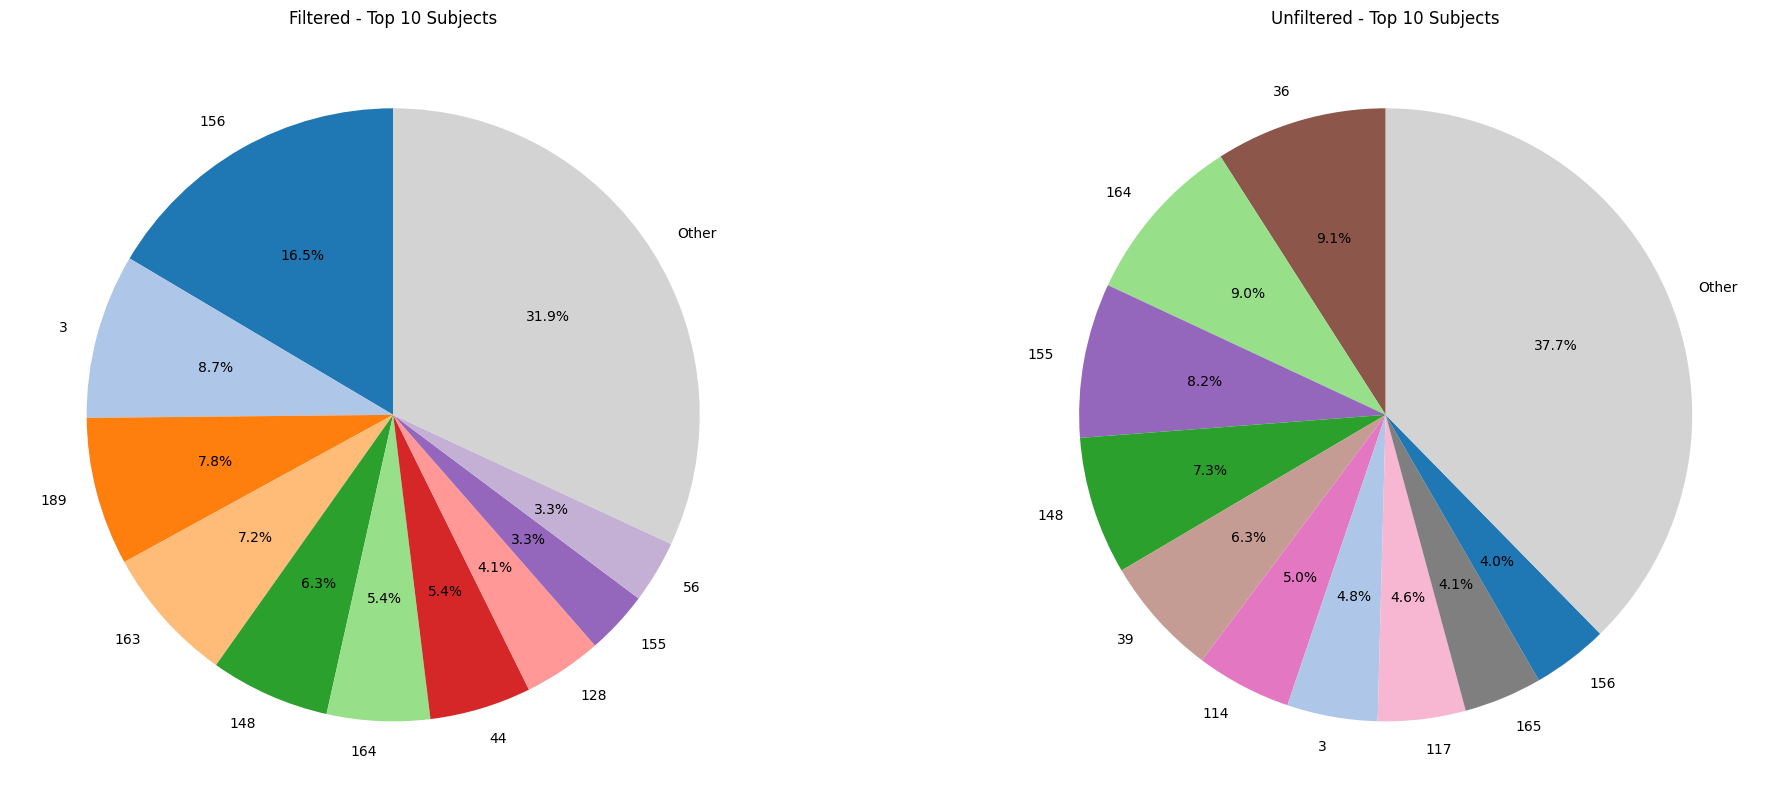

In [19]:
fig = plt.figure(figsize=(20, 16))
top_n = 10

# Get all unique subjects from both datasets and create color map
all_top_subjects = pd.concat([subj_counts_f.head(top_n), subj_counts_u.head(top_n)]).index.unique()
colors = plt.cm.tab20(range(len(all_top_subjects)))
color_map = {subj: colors[i] for i, subj in enumerate(all_top_subjects)}
color_map['Other'] = 'lightgray'

# Filtered pie
ax3 = plt.subplot(2, 2, 3)
top_filtered = subj_counts_f.head(top_n)
other_filtered = subj_counts_f.iloc[top_n:].sum()
pie_filtered = pd.concat([top_filtered, pd.Series({'Other': other_filtered})])
filtered_colors = [color_map.get(subj, 'gray') for subj in pie_filtered.index]
ax3.pie(pie_filtered, labels=pie_filtered.index, autopct='%1.1f%%', startangle=90, colors=filtered_colors)
ax3.set_title(f'Filtered - Top {top_n} Subjects')

# Unfiltered pie
ax4 = plt.subplot(2, 2, 4)
top_unfiltered = subj_counts_u.head(top_n)
other_unfiltered = subj_counts_u.iloc[top_n:].sum()
pie_unfiltered = pd.concat([top_unfiltered, pd.Series({'Other': other_unfiltered})])
unfiltered_colors = [color_map.get(subj, 'gray') for subj in pie_unfiltered.index]
ax4.pie(pie_unfiltered, labels=pie_unfiltered.index, autopct='%1.1f%%', startangle=90, colors=unfiltered_colors)
ax4.set_title(f'Unfiltered - Top {top_n} Subjects')

plt.tight_layout()
plt.show()